<a href="https://colab.research.google.com/github/tcplasma/TW300_Quant_Screener/blob/main/TW300_MultiFactor_Screener.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 台股市值前 300 大  量化多因子選股系統 v2.0
# 🔬 TW300 Multi-Factor Quantitative Screener

---

> **策略核心 Core Strategy**
>
> **價值 Value (40%) × 品質 Quality (30%) × 即時動能 Momentum (30%)**
>
> 格雷厄姆公式 Graham Formula：**PE × PB < 22.5** 額外加分

---

## 📐 指標速查表 | Indicator Reference

| 指標 | 計算邏輯 | 投資意義 | 金融含義 |
|------|---------|----------|----------|
| **P/E 本益比** | 股價 / EPS | < 15 低估 | 市場為每 $1 盈餘支付多少 |
| **P/B 本淨比** | 股價 / 每股淨值 | < 1.5 具安全邊際 | 市值相對帳面資產的溢價 |
| **格雷厄姆公式** | PE × PB < 22.5 | 雙重低估確認 | 班傑明·格雷厄姆設計的最嚴格價值標準 |
| **ROE%** | 淨利 / 股東權益 | > 12% 優質 | 巴菲特最重視：用股東錢賺錢的效率 |
| **營業利益率%** | 營業利益 / 營收 | 越高競爭力越強 | 本業真實獲利，排除業外收益干擾 |
| **量能倍數** | 今日量 / 5日均量 | > 1.5 有資金介入 | 資金流向的最即時指標 |
| **年線乖離%** | (價-MA200)/MA200 | < -15% 超跌 | 股價偏離長期均衡的程度 |

---

## 🔍 真突破 vs 假性反彈 辨別框架

| | 真突破 True Breakout | 假性反彈 Fake Rally |
|---|---|---|
| **量能** | 量能比 > 1.5（必要條件）| 量能比 < 1.2（縮量拉升）|
| **位階** | 站上 MA20 月線 | 仍在月線下方 |
| **基本面** | ROE > 12%（大戶願長抱）| ROE < 5%（純情緒炒作）|
| **年線** | 乖離 -25% 以內 | 已在前高附近 |
| **結論** | 隔日守住漲幅 | 隔日容易回吐 |

---

⚠️ **免責聲明 Disclaimer**：本筆記本僅供量化研究，不構成投資建議。數據來源 Yahoo Finance，可能有延遲。


## 📦 Step 1: 安裝套件 | Install Packages


In [1]:
# ── 安裝必要套件 Install required packages ────────────────────────
!pip install yfinance pandas numpy matplotlib -q

# ── 載入函式庫 Import libraries ───────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import warnings
import time
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Optional
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

print(f"✅ 所有套件載入完成 | All packages loaded")
print(f"📅 分析時間 Analysis time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ 所有套件載入完成 | All packages loaded
📅 分析時間 Analysis time: 2026-04-02 04:56:56


In [2]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2026-04-02 04:57:00--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 108.177.11.139, 108.177.11.113, 108.177.11.101, ...
Connecting to drive.google.com (drive.google.com)|108.177.11.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2026-04-02 04:57:00--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.216.132, 2607:f8b0:400c:c32::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.216.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  --.-KB/s    in 0.1s    

2026-04-02 04:5

## 📋 Step 2: 台股市值前 300 大成分股清單 | TW300 Component List

**中文說明：**
- 涵蓋上市（TWSE `.TW`）及上櫃（OTC `.TWO`）股票
- 依市值分類：超大型 / 大型 / 中型，包含半導體、金融、傳產、消費等各產業
- 每季度（3/6/9/12月）參考台灣證交所更新清單

**English:**
- Covers TWSE (`.TW`) and OTC (`.TWO`) listed stocks
- Categorized by market cap: Mega / Large / Mid-cap across all sectors
- Update quarterly from TWSE official data

> 💡 **Tip:** 若只想快速測試 10 檔，在 Step 5 設定 `QUICK_TEST = True`


In [3]:
# ══ 台股市值前 300 大成分股 TW300 Components (2026 Q1) ══════════════
# 格式 Format: "代號.TW": "中文名稱"

TW300 = {
    # ── 超大型股 Mega Cap (> 1 兆) ──────────────────────────────────
    "2330.TW": "台積電",    "2317.TW": "鴻海",      "2454.TW": "聯發科",
    "2308.TW": "台達電",    "2881.TW": "富邦金",    "2882.TW": "國泰金",
    "2412.TW": "中華電",    "2303.TW": "聯電",      "3711.TW": "日月光投控",

    # ── 大型股 Large Cap (3000-10000 億) ─────────────────────────────
    "2002.TW": "中鋼",      "1301.TW": "台塑",      "1303.TW": "南亞",
    "2886.TW": "兆豐金",    "2891.TW": "中信金",    "1326.TW": "台化",
    "2884.TW": "玉山金",    "2892.TW": "第一金",    "5880.TW": "合庫金",
    "2883.TW": "開發金",    "2885.TW": "元大金",    "2890.TW": "永豐金",
    "2887.TW": "台新金",    "6505.TW": "台塑化",    "3008.TW": "大立光",
    "2207.TW": "和泰車",    "2880.TW": "華南金",    "1216.TW": "統一",
    "2382.TW": "廣達",      "4938.TW": "和碩",      "2395.TW": "研華",
    "2379.TW": "瑞昱",      "2345.TW": "智邦",      "2357.TW": "華碩",
    "2327.TW": "國巨",      "3045.TW": "台灣大",    "4904.TW": "遠傳",
    "2912.TW": "統一超",    "1101.TW": "台泥",      "2354.TW": "鴻準",
    "2377.TW": "微星",      "2408.TW": "南亞科",    "2301.TW": "光寶科",
    "6669.TW": "緯穎",      "3034.TW": "聯詠",      "2603.TW": "長榮",
    "2609.TW": "陽明",      "2615.TW": "萬海",      "1590.TW": "亞德客",
    "8046.TW": "南電",      "2356.TW": "英業達",    "3231.TW": "緯創",
    "3017.TW": "奇鋐",      "2049.TW": "上銀",      "2353.TW": "宏碁",

    # ── 中型股 Mid Cap (800-3000 億) ─────────────────────────────────
    "2409.TW": "友達",      "3481.TW": "群創",      "2385.TW": "群光",
    "1402.TW": "遠東新",    "3533.TW": "嘉澤",      "2344.TW": "華邦電",
    "3037.TW": "欣興",      "2376.TW": "技嘉",      "6286.TW": "立錡",
    "2337.TW": "旺宏",      "5347.TW": "世界",      "3443.TW": "創意",
    "6239.TW": "力成",      "2458.TW": "義隆",      "6176.TW": "瑞儀",
    "3044.TW": "健鼎",      "2439.TW": "美律",      "4915.TW": "致伸",
    "2492.TW": "華新科",    "3005.TW": "神基",      "2474.TW": "可成",
    "3023.TW": "信邦",      "1476.TW": "儒鴻",      "2542.TW": "興富發",
    "5904.TW": "寶雅",      "2393.TW": "億光",      "2059.TW": "川湖",
    "2027.TW": "大成鋼",    "1434.TW": "福懋",      "2015.TW": "豐興",
    "1605.TW": "華新",      "9910.TW": "豐泰",      "9921.TW": "巨大",
    "9934.TW": "成霖",      "9939.TW": "宏全",      "9940.TW": "信義房屋",
    "9945.TW": "潤泰新",    "9917.TW": "中保科",    "9914.TW": "美利達",

    # ── 中型成長股 Growth Mid-Cap ────────────────────────────────────
    "6770.TW": "力積電",    "3189.TW": "景碩",      "3260.TW": "威剛",
    "3576.TW": "新日興",    "6146.TW": "耕興",      "2406.TW": "國碩",
    "6456.TW": "GIS-KY",   "3707.TW": "漢磊",      "6443.TW": "元晶",
    "3293.TW": "鈊象",      "6409.TW": "旭隼",      "5483.TW": "中美晶",
    "3105.TW": "穩懋",      "6462.TW": "神盾",      "3661.TW": "世芯-KY",
    "6533.TW": "晶心科",    "6488.TW": "環球晶",    "8016.TW": "矽創",

    # ── 金融股 Financials ────────────────────────────────────────────
    "2801.TW": "彰銀",      "2809.TW": "京城銀",    "2812.TW": "台中銀",
    "2823.TW": "中壽",      "2832.TW": "台產",      "2834.TW": "臺企銀",
    "2836.TW": "高雄銀",    "2838.TW": "聯邦銀",    "2845.TW": "遠東銀",
    "2850.TW": "新產",      "2851.TW": "中再保",    "2855.TW": "統一證",
    "5820.TW": "日盛金",    "6005.TW": "群益金鼎證", "2888.TW": "新光金",
    "2889.TW": "國票金",

    # ── 傳產 / 消費 Industrials & Consumer ──────────────────────────
    "1102.TW": "亞泥",      "1103.TW": "嘉泥",      "1201.TW": "味全",
    "1210.TW": "大成",      "1215.TW": "卜蜂",      "1217.TW": "愛之味",
    "1218.TW": "泰山",      "1219.TW": "福壽",      "1225.TW": "福懋油",
    "1227.TW": "佳格",      "1229.TW": "聯華",      "1232.TW": "大統益",
    "1234.TW": "黑松",      "1236.TW": "宏亞",      "2903.TW": "遠百",
    "2905.TW": "三商行",    "2915.TW": "潤泰全",    "9904.TW": "寶成",

    # ── 電子製造 Electronics ─────────────────────────────────────────
    "2312.TW": "金寶",      "2313.TW": "華通",      "2324.TW": "仁寶",
    "2347.TW": "聯強",      "2360.TW": "致茂",      "2362.TW": "藍天",
    "2367.TW": "燿華",      "2368.TW": "金像電",    "2371.TW": "大同",
    "2374.TW": "佳能",      "2375.TW": "智原",      "2383.TW": "台光電",
    "2392.TW": "正崴",      "2394.TW": "晶豪科",    "2399.TW": "映泰",
    "2401.TW": "凌陽",      "2404.TW": "漢唐",      "2407.TW": "美格納",
    "2410.TW": "正文",      "2413.TW": "環科",      "2415.TW": "錩泰",
}

# 去除重複，限制 300 檔
TW300 = dict(list({k: v for k, v in TW300.items()}.items())[:300])

# 統計
by_suffix = {"上市 TWSE (.TW)": sum(1 for k in TW300 if k.endswith(".TW")),
             "上櫃 OTC (.TWO)": sum(1 for k in TW300 if k.endswith(".TWO"))}

print(f"📋 成分股清單載入完成 | Component list loaded")
print(f"   總數 Total: {len(TW300)} 檔")
for k, v in by_suffix.items():
    print(f"   {k}: {v} 檔")


📋 成分股清單載入完成 | Component list loaded
   總數 Total: 166 檔
   上市 TWSE (.TW): 166 檔
   上櫃 OTC (.TWO): 0 檔


## 🔧 Step 3: 單股數據抓取引擎 | Single Stock Fetch Engine

**中文說明：** 此函數抓取單一股票的技術面（均線、量能）與基本面（PE/PB/ROE）數據。  
內建完整 `try-except` 錯誤處理：停牌、數據缺失、API 超時均自動跳過，不中斷主程式。

**English:** Fetches both technical (MA, volume) and fundamental (PE/PB/ROE) data for each stock.  
Full `try-except` error handling: suspended stocks, missing data, or API timeouts are silently skipped.


In [4]:
def fetch_single_stock(ticker: str, name: str, period_years: int = 2) -> Optional[dict]:
    """
    抓取單一股票完整量化因子數據。
    Fetch complete quantitative factor data for a single stock.

    設計要點 Design Notes:
    - try/except 全包，任何錯誤靜默返回 None
    - period_years=2 只抓兩年，平衡速度與均線計算需求
    - 量能激增比：今日量 / 5日均量（最即時的資金流向指標）
    """
    try:
        end_dt   = datetime.now()
        start_dt = end_dt - timedelta(days=365 * period_years)

        # ── 下載日 K 線 | Download daily OHLCV ─────────────────────
        hist = yf.download(
            ticker,
            start=start_dt.strftime('%Y-%m-%d'),
            end=end_dt.strftime('%Y-%m-%d'),
            progress=False,
            auto_adjust=True
        )

        if hist is None or len(hist) < 60:
            return None

        stock = yf.Ticker(ticker)
        info  = stock.info

        close  = hist['Close'].squeeze()
        volume = hist['Volume'].squeeze()

        if len(close) < 5:
            return None

        price  = float(close.iloc[-1])
        prev_p = float(close.iloc[-2]) if len(close) > 1 else price

        # ── 均線 Moving Averages ─────────────────────────────────────
        # 金融意義：均線代表市場在該段時間內的平均持倉成本
        # Financial: MAs represent the average market holding cost over that period
        ma20  = float(close.rolling(20).mean().iloc[-1])
        ma60  = float(close.rolling(60).mean().iloc[-1])
        ma200 = float(close.rolling(200).mean().iloc[-1]) if len(close)>=200 else float('nan')
        prev_ma20 = float(close.rolling(20).mean().iloc[-2]) if len(close)>20 else ma20

        # ── 量能激增比 Volume Surge Ratio ───────────────────────────
        # > 1.5 = 異常資金介入  |  > 2.0 = 強烈買盤確認  |  > 3.0 = 可能有重大消息
        # > 1.5 = Unusual capital inflow  |  > 2.0 = Strong buy confirmation
        vol_5d    = float(volume.rolling(5).mean().iloc[-1])
        vol_ratio = float(volume.iloc[-1]) / vol_5d if vol_5d > 0 else 1.0

        # ── 站上 MA20（趨勢轉折訊號）Cross Above MA20 ───────────────
        crossed_ma20 = bool(prev_p < prev_ma20 and price >= ma20)

        # ── 年線乖離率 MA200 Deviation ──────────────────────────────
        # 負值代表低於年線；< -15% 超跌；< -20% 嚴重超跌
        # Negative = below annual MA; < -15% oversold; < -20% severely oversold
        ma200_dev = ((price - ma200) / ma200 * 100) if (ma200==ma200) else float('nan')

        # 當日漲跌幅 Daily change %
        day_chg = ((price - prev_p) / prev_p * 100) if prev_p > 0 else 0.0

        # 60 日位階（股價在近 60 日高低點之間的百分位）
        # 60-day position: percentile within recent 60-day range
        high_60 = float(close.tail(60).max())
        low_60  = float(close.tail(60).min())
        pos_in_range = ((price - low_60) / (high_60 - low_60) * 100) if high_60>low_60 else 50.0

        # ── 估值面 Valuation ─────────────────────────────────────────
        pe_ratio = info.get('trailingPE',    float('nan'))
        pb_ratio = info.get('priceToBook',   float('nan'))
        mkt_cap  = info.get('marketCap',     float('nan'))

        # 格雷厄姆公式：PE × PB < 22.5
        # 班傑明·格雷厄姆設計的雙重低估標準 Benjamin Graham's dual undervaluation criterion
        graham_ok = False
        if (pe_ratio==pe_ratio and pb_ratio==pb_ratio and pe_ratio>0 and pb_ratio>0):
            graham_ok = bool(pe_ratio * pb_ratio < 22.5)

        # ── 品質面 Quality ───────────────────────────────────────────
        roe       = info.get('returnOnEquity',   float('nan'))
        op_margin = info.get('operatingMargins', float('nan'))
        div_yield = info.get('dividendYield',    float('nan'))

        roe       = roe*100       if (roe and roe==roe)             else float('nan')
        op_margin = op_margin*100 if (op_margin and op_margin==op_margin) else float('nan')
        div_yield = div_yield*100 if (div_yield and div_yield==div_yield) else float('nan')

        # ── 市值分類 Market Cap Classification ──────────────────────
        if mkt_cap==mkt_cap and mkt_cap>0:
            mkt_cap_b = mkt_cap / 1e8
            if   mkt_cap_b > 10000: cap_class = "超大型 Mega"
            elif mkt_cap_b > 3000:  cap_class = "大型 Large"
            elif mkt_cap_b > 800:   cap_class = "中型 Mid"
            else:                   cap_class = "小型 Small"
        else:
            mkt_cap_b = float('nan')
            cap_class = "未知"

        return {
            "代號":        ticker.replace(".TW","").replace(".TWO",""),
            "名稱":        name,
            "現價":        round(price, 1),
            "當日漲跌%":   round(day_chg, 2),
            "PE本益比":    round(pe_ratio, 1)  if pe_ratio==pe_ratio   else float('nan'),
            "PB本淨比":    round(pb_ratio, 2)  if pb_ratio==pb_ratio   else float('nan'),
            "殖利率%":     round(div_yield, 2) if div_yield==div_yield else float('nan'),
            "格雷厄姆":    graham_ok,
            "ROE%":        round(roe, 1)        if roe==roe             else float('nan'),
            "營業利益率%": round(op_margin, 1)  if op_margin==op_margin else float('nan'),
            "MA20":        round(ma20, 1),
            "MA60":        round(ma60, 1),
            "MA200":       round(ma200, 1)      if ma200==ma200         else float('nan'),
            "量能倍數":    round(vol_ratio, 2),
            "站上MA20":    crossed_ma20,
            "年線乖離%":   round(ma200_dev, 1)  if ma200_dev==ma200_dev else float('nan'),
            "60日位階%":   round(pos_in_range, 1),
            "市值億":      round(mkt_cap_b, 0)  if mkt_cap_b==mkt_cap_b else float('nan'),
            "市值分類":    cap_class,
        }

    except Exception:
        return None   # 靜默跳過所有錯誤 | Silently skip all errors


print("✅ 數據抓取函式定義完成 | Fetch function defined")
print("   支援 try-except 全包 + 自動跳過失敗標的")


✅ 數據抓取函式定義完成 | Fetch function defined
   支援 try-except 全包 + 自動跳過失敗標的


## 🧮 Step 4: 多因子評分引擎 | Multi-Factor Scoring Engine

**中文說明：** `calculate_score()` 將三層因子整合為 0-100 分的量化評分。  
**English:** `calculate_score()` consolidates three factor layers into a 0-100 composite score.

```
價值 Value    (40pts): PE < 15 → 12-18pts | PB < 1.5 → 9-12pts | 格雷厄姆 → +7pts
品質 Quality  (30pts): ROE > 12% → 9-18pts | 營業利益率 > 10% → 7-10pts
動能 Momentum (30pts): 量能 > 1.5x → 6-12pts | 站上MA20 → +10pts | 超跌 → +4-8pts
```


In [5]:
def calculate_score(row: pd.Series) -> float:
    """
    多因子量化評分函數（0-100 分）
    Multi-Factor Quantitative Scoring Function (0-100 pts)

    ┌──────────────────────────────────────────────────────────┐
    │ 分項        權重   評分邏輯                                │
    ├──────────────────────────────────────────────────────────┤
    │ 價值 Value  40%   PE<8→18, PE<12→15, PE<15→12           │
    │                   PB<0.8→15, PB<1.0→12, PB<1.5→9       │
    │                   格雷厄姆 PE×PB<22.5 → +7              │
    │ 品質 Quality 30%  ROE>25→18, ROE>15→12, ROE>12→9       │
    │                   Op.Margin>15→10, >10→7, >5→4         │
    │ 動能 Momentum 30% Vol>4x→12, >2x→8, >1.5x→6           │
    │                   站上MA20 → +10                        │
    │                   年線乖離<-25%→8, <-15%→6, <-10%→4    │
    └──────────────────────────────────────────────────────────┘
    """
    score = 0.0

    # ═══ 價值項 Value Layer (max 40 pts) ══════════════════════════

    pe = row.get("PE本益比", float('nan'))
    pb = row.get("PB本淨比", float('nan'))

    # P/E 評分：本益比越低 = 市場對盈餘的估值越便宜
    # P/E scoring: lower PE = market pays less per $1 of earnings
    if pe==pe and pe>0:
        if   pe < 8:   score += 18   # 極度低估 Extremely undervalued
        elif pe < 12:  score += 15   # 低估 Undervalued
        elif pe < 15:  score += 12   # 合理偏低 Reasonably low
        elif pe < 20:  score += 6    # 合理 Fair
        elif pe < 25:  score += 2    # 稍貴 Slightly expensive

    # P/B 評分：本淨比越低 = 資產保護越強（< 1 可以折價買資產）
    # P/B scoring: lower PB = stronger asset protection (< 1 = buying assets at discount)
    if pb==pb and pb>0:
        if   pb < 0.8: score += 15   # 嚴重低估 Severely undervalued
        elif pb < 1.0: score += 12   # 低於帳面值 Below book value
        elif pb < 1.5: score += 9    # 合理低 Reasonably low
        elif pb < 2.0: score += 5    # 合理 Fair
        elif pb < 3.0: score += 2    # 稍高 Slightly high

    # 格雷厄姆公式加分 Graham Formula bonus
    # PE × PB < 22.5 是班傑明·格雷厄姆設計的「雙重低估」安全邊際公式
    # Designed by Benjamin Graham as the strictest "dual undervaluation" safety margin
    if row.get("格雷厄姆", False):
        score += 7

    # ═══ 品質項 Quality Layer (max 30 pts) ════════════════════════

    roe = row.get("ROE%", float('nan'))
    op  = row.get("營業利益率%", float('nan'))

    # ROE 評分：用股東的錢創造回報的效率（巴菲特最重視）
    # ROE scoring: efficiency of generating returns with shareholder equity (Buffett's #1 metric)
    if roe==roe:
        if   roe > 25: score += 18   # 頂級護城河 Top-tier moat
        elif roe > 20: score += 15   # 優質 High quality
        elif roe > 15: score += 12   # 良好 Good
        elif roe > 12: score += 9    # 及格門檻 Passing threshold
        elif roe > 8:  score += 5    # 一般 Average
        elif roe > 0:  score += 2    # 薄利 Thin profit
        # roe<=0: 虧損不加分 Loss-making, no points

    # 營業利益率：反映本業真實競爭力，排除業外收益
    # Operating margin: reflects true core competitiveness, excludes non-operating gains
    if op==op:
        if   op > 25:  score += 12   # 極高護城河 Exceptional moat
        elif op > 15:  score += 10   # 優質 High quality
        elif op > 10:  score += 7    # 良好 Good
        elif op > 5:   score += 4    # 一般 Average
        elif op > 0:   score += 1    # 薄利 Thin

    # ═══ 動能項 Momentum Layer (max 30 pts) ═══════════════════════

    vol   = row.get("量能倍數",  1.0)
    cross = row.get("站上MA20", False)
    dev   = row.get("年線乖離%", float('nan'))

    # 量能激增評分：資金流向的最即時指標
    # Volume surge: the most real-time capital flow indicator
    if   vol > 4.0:  score += 12   # 爆量（重大消息等級）Massive volume
    elif vol > 3.0:  score += 10   # 強勁爆量 Strong surge
    elif vol > 2.0:  score += 8    # 明顯放量 Clear expansion
    elif vol > 1.5:  score += 6    # 量能擴張 Volume expanding
    elif vol > 1.2:  score += 3    # 量能略增 Mild increase

    # 站上月線：短期趨勢由空轉多的關鍵技術訊號
    # Cross above MA20: key signal of short-term trend reversal from bearish to bullish
    if cross:
        score += 10

    # 年線乖離率：超跌反彈的核心指標
    # MA200 deviation: core oversold rebound indicator
    if dev==dev:
        if   dev < -25: score += 8   # 嚴重超跌，歷史低點 Severely oversold
        elif dev < -15: score += 6   # 明顯超跌 Clearly oversold
        elif dev < -10: score += 4   # 偏低 Below average
        elif dev < -5:  score += 2   # 略低 Slightly below
        elif dev > 10:  score -= 2   # 已偏高，動能不利 Elevated, less momentum room

    return min(round(score, 1), 100.0)


# ── 探勘結論分類 Classify Conclusions ────────────────────────────────
def classify_conclusion(row: pd.Series) -> str:
    """依多因子組合判定標籤 | Classify based on multi-factor combo"""
    score = row.get("綜合得分", 0)
    vol   = row.get("量能倍數", 1.0)
    cross = row.get("站上MA20", False)
    roe   = row.get("ROE%", float('nan'))
    dev   = row.get("年線乖離%", float('nan'))
    pe    = row.get("PE本益比",  float('nan'))
    chg   = row.get("當日漲跌%", 0.0)
    pos60 = row.get("60日位階%", 50.0)

    roe_ok   = (roe==roe and roe > 12)
    dev_deep = (dev==dev and dev < -20)
    dev_ok   = (dev==dev and dev < -10)

    if score > 80 and vol > 2.0 and roe_ok and pe==pe and pe < 15:
        return "💎 絕佳寶藏：量價齊揚低估股"
    if score > 70 and vol > 1.5 and cross and roe_ok:
        return "🚀 真突破：量能確認趨勢轉多"
    if score > 65 and dev_deep and roe_ok:
        return "⭐ 超跌黃金：體質優但嚴重超賣"
    if score > 70 and dev_ok:
        return "🏗️ 緩步築底：價值修復股"
    if score > 65:
        return "📋 高潛力：進入觀察名單"
    if chg > 5 and vol < 1.2 and not roe_ok:
        return "⚠️ 警示：疑似假性反彈"
    if chg > 3 and vol < 1.0 and pos60 > 80:
        return "🔴 高位量縮：謹慎追高"
    return "— 一般觀察"


# ── 突破可信度分析 Breakout Credibility ─────────────────────────────
def breakout_credibility(row: pd.Series) -> str:
    """
    【真突破 vs 假性反彈】突破可信度評分（0-5 顆星）
    True Breakout vs Fake Rally — Credibility Score (0-5 stars)

    判斷邏輯 Logic:
    ① 量能比（最關鍵）: > 3x → +2分  |  > 1.5x → +1分
    ② 站上MA20: → +1分
    ③ ROE > 12%（基本面支撐）: → +1分  |  ROE < 5% → -1分
    ④ PE > 30（追高風險）: → -1分
    """
    vol   = row.get("量能倍數",  1.0)
    cross = row.get("站上MA20", False)
    roe   = row.get("ROE%",     float('nan'))
    pe    = row.get("PE本益比",  float('nan'))

    stars = 0
    if   vol > 3.0: stars += 2
    elif vol > 1.5: stars += 1
    if cross:       stars += 1
    if roe==roe and roe > 12: stars += 1
    elif roe==roe and roe < 5: stars -= 1
    if pe==pe and pe > 30:    stars -= 1
    stars = max(0, min(5, stars))

    labels = {
        5: "🟢🟢🟢 極高可信度 True Breakout",
        4: "🟢🟢   高可信度 Likely Breakout",
        3: "🟡     中等 Neutral — Watch",
        2: "🟠     低可信度 Likely Fake",
        1: "🔴     高假反彈風險 Fake Rally",
        0: "🔴🔴   假反彈特徵明顯 Clear Fake",
    }
    return labels.get(stars, "— N/A")


print("✅ 評分函式與分類函式定義完成 | All scoring functions defined")
print()
print("📊 評分系統摘要 Scoring Summary:")
print("   價值 Value:    最高 40 pts  (PE+PB+Graham)")
print("   品質 Quality:  最高 30 pts  (ROE+Op.Margin)")
print("   動能 Momentum: 最高 30 pts  (Volume+MA20+MA200)")
print("   ─────────────────────────────────")
print("   總計 Total:    最高 100 pts")


✅ 評分函式與分類函式定義完成 | All scoring functions defined

📊 評分系統摘要 Scoring Summary:
   價值 Value:    最高 40 pts  (PE+PB+Graham)
   品質 Quality:  最高 30 pts  (ROE+Op.Margin)
   動能 Momentum: 最高 30 pts  (Volume+MA20+MA200)
   ─────────────────────────────────
   總計 Total:    最高 100 pts


## ⚡ Step 5: 多執行緒批量抓取 | Multithreaded Batch Fetch

**中文說明：**
- `ThreadPoolExecutor` 並行抓取，速度比逐一抓取快 **6-8 倍**
- 每批次結束後自動暫停，防止 Yahoo Finance API 封鎖
- 即時進度條顯示完成狀況

**English:**
- `ThreadPoolExecutor` parallel fetch — **6-8x faster** than sequential
- Auto-pause between batches prevents Yahoo Finance rate limiting
- Real-time progress bar shows completion status

> 💡 `QUICK_TEST = True` 只跑前 15 檔，適合快速驗證系統


In [7]:
# ════════════════════════════════════════════════════════════════
#  ⚙️ 執行設定 Configuration
# ════════════════════════════════════════════════════════════════

QUICK_TEST   = False   # True = 只抓前 15 檔測試 | True = test with 15 stocks only
MAX_WORKERS  = 8       # 並行執行緒數（建議 6-10）| Parallel threads (6-10 recommended)
BATCH_DELAY  = 0.5     # 批次間暫停秒數 | Pause between batches (seconds)

# ════════════════════════════════════════════════════════════════
#  多執行緒抓取引擎 Multithreaded Fetch Engine
# ════════════════════════════════════════════════════════════════

components = dict(list(TW300.items())[:15]) if QUICK_TEST else TW300
mode_label = "⚡ 快速測試 Quick Test (15 stocks)" if QUICK_TEST else f"📊 完整模式 Full Mode ({len(components)} stocks)"

print("=" * 60)
print("  🔍  台股前 300 大  量化多因子選股系統")
print("  🔍  TW300 Multi-Factor Quantitative Screener")
print(f"  📅  {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)
print(f"""
  模式 Mode: {mode_label}""")
print(f"""  執行緒 Threads: {MAX_WORKERS}
""")

# ── 執行並行抓取 ─────────────────────────────────────────────────
results  = []
failed   = []
total    = len(components)
items    = list(components.items())
batch_sz = MAX_WORKERS * 2

start_ts = time.time()

for batch_idx in range(0, total, batch_sz):
    batch = items[batch_idx : batch_idx + batch_sz]

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {
            executor.submit(fetch_single_stock, ticker, name): (ticker, name)
            for ticker, name in batch
        }
        for future in as_completed(futures):
            ticker, name = futures[future]
            try:
                data = future.result(timeout=15)
                if data:
                    results.append(data)
                else:
                    failed.append(ticker)
            except Exception:
                failed.append(ticker)

            done    = len(results) + len(failed)
            pct     = done / total * 100
            elapsed = time.time() - start_ts
            bar     = "█" * int(pct // 5) + "░" * (20 - int(pct // 5))
            print(f"\r  [{bar}] {pct:5.1f}%  ✓{len(results):3d} ✗{len(failed):3d}  "
                  f"⏱ {elapsed:.0f}s", end="", flush=True)

    if batch_idx + batch_sz < total:
        time.sleep(BATCH_DELAY)

elapsed_total = time.time() - start_ts
print(f"\n\n✅ 抓取完成 Done: {len(results)} 成功 | {len(failed)} 跳過 | 耗時 {elapsed_total:.1f}s")

# ── 建立 DataFrame & 計算評分 Build DataFrame & Score ───────────
if results:
    df = pd.DataFrame(results)
    print("\n🧮 計算多因子評分中... Computing scores...")
    df["綜合得分"] = df.apply(calculate_score, axis=1)
    df["探勘結論"] = df.apply(classify_conclusion, axis=1)
    df["突破可信度"] = df.apply(breakout_credibility, axis=1)
    df = df.sort_values("綜合得分", ascending=False).reset_index(drop=True)
    df.index += 1
    print(f"✅ 評分完成！共 {len(df)} 檔  最高分：{df['綜合得分'].max():.1f}  平均分：{df['綜合得分'].mean():.1f}")
else:
    print("❌ 無法取得任何數據，請檢查網路連線")

  🔍  台股前 300 大  量化多因子選股系統
  🔍  TW300 Multi-Factor Quantitative Screener
  📅  2026-04-02 04:58:12

  模式 Mode: 📊 完整模式 Full Mode (166 stocks)
  執行緒 Threads: 8

  [░░░░░░░░░░░░░░░░░░░░]   4.8%  ✓  8 ✗  0  ⏱ 2s

ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


  [████░░░░░░░░░░░░░░░░]  23.5%  ✓ 32 ✗  7  ⏱ 5s

ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


  [███████░░░░░░░░░░░░░]  38.6%  ✓ 56 ✗  8  ⏱ 18s

...

  [██████████████████░░]  92.8%  ✓125 ✗ 29  ⏱ 27s

ERROR:yfinance:['5820.TW']: YFTzMissingError('possibly delisted; no timezone found')


  [██████████████████░░]  94.0%  ✓125 ✗ 31  ⏱ 27s

ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
ERROR:yfinance:HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


  [████████████████████] 100.0%  ✓135 ✗ 31  ⏱ 29s

✅ 抓取完成 Done: 135 成功 | 31 跳過 | 耗時 29.1s

🧮 計算多因子評分中... Computing scores...
✅ 評分完成！共 135 檔  最高分：56.0  平均分：23.9


## 📊 Step 6: 最終探勘報告 | Final Discovery Report

**中文說明：** 輸出 `final_report`，按綜合得分排序，包含所有核心指標與探勘結論。  
**English:** Output `final_report`, sorted by composite score, with all key metrics and conclusions.


In [8]:
# ── Final Report 表格 ────────────────────────────────────────────
report_cols = [
    "代號", "名稱", "現價", "當日漲跌%",
    "PE本益比", "PB本淨比", "ROE%", "量能倍數",
    "年線乖離%", "站上MA20", "60日位階%",
    "綜合得分", "探勘結論", "突破可信度"
]

final_report = df[[c for c in report_cols if c in df.columns]].copy()
final_report["站上MA20"] = final_report["站上MA20"].map({True: "✅", False: "—"})

print("=" * 100)
print("  📋  最終探勘報告 Final Report  |  Top 25 綜合得分排行")
print("=" * 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)
pd.set_option('display.float_format', '{:.1f}'.format)
display(final_report.head(25))

# ── 各類別標的列表 ──────────────────────────────────────────────
print("\n" + "─"*70)
print("  📊  探勘結論統計 Signal Distribution")
print("─"*70)
for label, count in df["探勘結論"].value_counts().items():
    bar = "█" * min(count, 25)
    print(f"  {str(label):<35} {bar}  {count} 檔")


  📋  最終探勘報告 Final Report  |  Top 25 綜合得分排行


,代號,名稱,現價,當日漲跌%,PE本益比,PB本淨比,ROE%,量能倍數,年線乖離%,站上MA20,60日位階%,綜合得分,探勘結論,突破可信度
1,2801,彰銀,81.7,2.0,13.7,1.1,8.4,1.2,-27.9,—,6.7,56.0,— 一般觀察,🔴🔴 假反彈特徵明顯 Clear Fake
2,2834,臺企銀,332.0,6.1,12.2,1.0,8.8,1.1,110.7,✅,78.1,53.0,⚠️ 警示：疑似假性反彈,🔴 高假反彈風險 Fake Rally
3,2812,台中銀,332.0,6.1,13.6,1.4,10.4,1.1,110.7,✅,78.1,53.0,⚠️ 警示：疑似假性反彈,🔴 高假反彈風險 Fake Rally
4,2845,遠東銀,332.0,6.1,13.6,0.9,6.4,1.1,110.7,✅,78.1,53.0,⚠️ 警示：疑似假性反彈,🔴 高假反彈風險 Fake Rally
5,2615,萬海,331.0,3.9,7.0,0.8,11.7,0.7,4.7,—,56.0,52.0,— 一般觀察,🔴🔴 假反彈特徵明顯 Clear Fake
6,2832,台產,332.0,6.1,12.1,1.0,10.3,1.1,110.7,✅,78.1,51.0,⚠️ 警示：疑似假性反彈,🔴 高假反彈風險 Fake Rally
7,2855,統一證,21.3,0.2,10.7,1.3,12.9,0.6,122.3,—,70.9,50.0,— 一般觀察,🔴 高假反彈風險 Fake Rally
8,6005,群益金鼎證,54.4,4.8,10.5,1.3,13.2,0.9,11.0,—,60.5,50.0,— 一般觀察,🔴 高假反彈風險 Fake Rally
9,2603,長榮,331.0,3.9,6.4,0.8,11.8,0.7,4.7,—,56.0,49.0,— 一般觀察,🔴🔴 假反彈特徵明顯 Clear Fake
10,2836,高雄銀,332.0,6.1,18.1,0.8,4.9,1.1,110.7,✅,78.1,47.0,⚠️ 警示：疑似假性反彈,🔴🔴 假反彈特徵明顯 Clear Fake



──────────────────────────────────────────────────────────────────────
  📊  探勘結論統計 Signal Distribution
──────────────────────────────────────────────────────────────────────
  — 一般觀察                              █████████████████████████  113 檔
  ⚠️ 警示：疑似假性反彈                        █████████████████  17 檔
  🔴 高位量縮：謹慎追高                         █████  5 檔


## 🔬 Step 7: 真突破 vs 假性反彈 深度分析
## 🔬 Step 7: True Breakout vs Fake Rally — Deep Analysis

> **背景 Context:** 在 4/1 這類指數千點大漲日，幾乎所有股票都會被拉升。  
> 真正的問題是：**哪些股票的漲幅是可以持續的？哪些只是搭順風車？**
>
> **Background:** On a massive rally day like 4/1, almost all stocks rise.  
> The real question is: **Which gains are sustainable? Which are just riding the wave?**


In [9]:
# ════════════════════════════════════════════════════════════════
#  真突破 vs 假性反彈 辨別框架
#  True Breakout vs Fake Rally — Identification Framework
# ════════════════════════════════════════════════════════════════

print("╔" + "═"*72 + "╗")
print("║  🔬  真突破 vs 假性反彈  |  True Breakout vs Fake Rally Framework  ║")
print("╠" + "═"*72 + "╣")
print("║                                                                        ║")
print("║  【真突破 4 要素 True Breakout — Must Have ALL 4】                     ║")
print("║  ① 量能比 > 1.5（資金確認，大戶在買）                                  ║")
print("║     Volume ratio > 1.5x (institutional money entering)                 ║")
print("║  ② 站上 MA20（月線壓力已突破，技術面轉多）                              ║")
print("║     Price crossed above MA20 (key technical trend reversal)             ║")
print("║  ③ ROE > 12%（基本面撐盤，大戶願意長抱）                               ║")
print("║     ROE > 12% (fundamentals support, institutions willing to hold)      ║")
print("║  ④ 年線乖離在 -25% 以內（非死股，有反彈空間）                           ║")
print("║     MA200 deviation > -25% (not a dying stock, has rebound room)        ║")
print("║                                                                        ║")
print("║  【假反彈 4 特徵 Fake Rally — Warning Signs】                           ║")
print("║  ① 量能比 < 1.2（縮量反彈，大戶在出貨）                                ║")
print("║     Volume ratio < 1.2x (low volume rally, institutions distributing)   ║")
print("║  ② 仍在 MA20 下方（技術面仍弱）                                         ║")
print("║     Still below MA20 (technically still weak)                           ║")
print("║  ③ ROE < 5%（爛公司被指數帶飛，無法持續）                              ║")
print("║     ROE < 5% (poor company riding index, unsustainable)                 ║")
print("║  ④ 60 日位階 > 80%（接近前高，上方壓力沉重）                            ║")
print("║     60-day position > 80% (near resistance, heavy overhead supply)      ║")
print("║                                                                        ║")
print("║  【最強訊號 Strongest Signal Combo】                                    ║")
print("║  綜合得分 > 80 + 年線乖離 < -20% + 量能比 > 2.5                        ║")
print("║  Score > 80 + MA200 dev < -20% + Volume ratio > 2.5                    ║")
print("║  → 體質極好被過度懲罰，大戶趁亂掃貨 = 夢寐以求的數據寶藏               ║")
print("║  → Quality stock punished too hard, institutions buying = Data gem      ║")
print("╚" + "═"*72 + "╝")

print()

# ── 今日各等級標的 ──────────────────────────────────────────────
levels = [
    ("💎 絕佳寶藏",  "絕佳寶藏",  "最優先研究：量價齊揚 × 估值低 × 品質好"),
    ("🚀 真突破",    "真突破",    "強力關注：量能確認趨勢轉多"),
    ("⭐ 超跌黃金",  "超跌黃金",  "中期布局：等量能放大時進場"),
    ("⚠️ 假性反彈",  "假性反彈",  "警示：避免追高，可能次日回吐"),
]

for emoji, keyword, desc in levels:
    subset = df[df["探勘結論"].str.contains(keyword, na=False)]
    print(f"\n{emoji} {desc} — {len(subset)} 檔")
    if len(subset) > 0:
        show_cols = ["代號","名稱","PE本益比","PB本淨比","ROE%",
                     "量能倍數","年線乖離%","綜合得分","突破可信度"]
        display(subset[[c for c in show_cols if c in subset.columns]].head(8))

# ── 最強訊號組合篩選 ────────────────────────────────────────────
print("\n" + "🏆 "*20)
print("\n🔥  最強訊號組合：綜合得分 > 80 + 年線乖離 < -20% + 量能比 > 2.5")
print("    The Ultimate Data Gem: Score>80 + MA200 dev<-20% + Vol>2.5x")
print("🏆 "*20)

ultimate = df[
    (df["綜合得分"] > 80) &
    (df["年線乖離%"] < -20) &
    (df["量能倍數"] > 2.5)
].copy()

if len(ultimate) > 0:
    print(f"\n  ✨ 今日發現 {len(ultimate)} 檔「夢寐以求的數據寶藏」！")
    display(ultimate[["代號","名稱","現價","當日漲跌%","PE本益比","PB本淨比",
                       "ROE%","量能倍數","年線乖離%","綜合得分","突破可信度"]])
else:
    print("\n  今日無符合最強條件的標的（門檻極高，出現時千萬不要錯過）")
    print("  No stocks meet the ultimate criteria today (threshold is very high)")
    # 放寬條件給用戶參考
    relaxed = df[
        (df["綜合得分"] > 70) &
        (df["年線乖離%"] < -15) &
        (df["量能倍數"] > 1.5)
    ].head(5)
    if len(relaxed) > 0:
        print(f"\n  📋 放寬條件（得分>70 + 乖離<-15% + 量>1.5x）→ {len(relaxed)} 檔:")
        display(relaxed[["代號","名稱","ROE%","量能倍數","年線乖離%","綜合得分"]])


╔════════════════════════════════════════════════════════════════════════╗
║  🔬  真突破 vs 假性反彈  |  True Breakout vs Fake Rally Framework  ║
╠════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  【真突破 4 要素 True Breakout — Must Have ALL 4】                     ║
║  ① 量能比 > 1.5（資金確認，大戶在買）                                  ║
║     Volume ratio > 1.5x (institutional money entering)                 ║
║  ② 站上 MA20（月線壓力已突破，技術面轉多）                              ║
║     Price crossed above MA20 (key technical trend reversal)             ║
║  ③ ROE > 12%（基本面撐盤，大戶願意長抱）                               ║
║     ROE > 12% (fundamentals support, institutions willing to hold)      ║
║  ④ 年線乖離在 -25% 以內（非死股，有反彈空間）                           ║
║     MA200 deviation > -25% (not a dying stock, has rebound room)        ║
║                                                                        ║
║  【假反彈 4 特徵 Fake Rally — W

,代號,名稱,PE本益比,PB本淨比,ROE%,量能倍數,年線乖離%,綜合得分,突破可信度
2,2834,臺企銀,12.2,1.0,8.8,1.1,110.7,53.0,🔴 高假反彈風險 Fake Rally
3,2812,台中銀,13.6,1.4,10.4,1.1,110.7,53.0,🔴 高假反彈風險 Fake Rally
4,2845,遠東銀,13.6,0.9,6.4,1.1,110.7,53.0,🔴 高假反彈風險 Fake Rally
6,2832,台產,12.1,1.0,10.3,1.1,110.7,51.0,🔴 高假反彈風險 Fake Rally
10,2836,高雄銀,18.1,0.8,4.9,1.1,110.7,47.0,🔴🔴 假反彈特徵明顯 Clear Fake
16,2838,聯邦銀,16.1,1.1,7.3,1.1,110.7,44.0,🔴 高假反彈風險 Fake Rally
30,2882,國泰金,10.2,1.1,11.7,0.9,-5.5,38.0,🔴🔴 假反彈特徵明顯 Clear Fake
39,2317,鴻海,14.3,1.5,11.3,0.9,-5.5,32.0,🔴🔴 假反彈特徵明顯 Clear Fake



🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 

🔥  最強訊號組合：綜合得分 > 80 + 年線乖離 < -20% + 量能比 > 2.5
    The Ultimate Data Gem: Score>80 + MA200 dev<-20% + Vol>2.5x
🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 

  今日無符合最強條件的標的（門檻極高，出現時千萬不要錯過）
  No stocks meet the ultimate criteria today (threshold is very high)


## 📈 Step 8: 風險/回報矩陣圖 | Risk/Return Matrix Chart

- **X 軸 P/B**：越低 = 估值越便宜（< 1.5 具安全邊際）  
- **Y 軸 ROE%**：越高 = 獲利能力越強（> 12% 為品質門檻）  
- **顏色深淺**：量能倍數（越亮 = 資金介入越強，使用 `plasma` 色盤）  
- **氣泡大小**：綜合得分（越大 = 越值得關注）

> 🏆 **最佳投資區間**：左上角（低 P/B + 高 ROE + 亮色氣泡）= 低估 × 優質 × 有量能


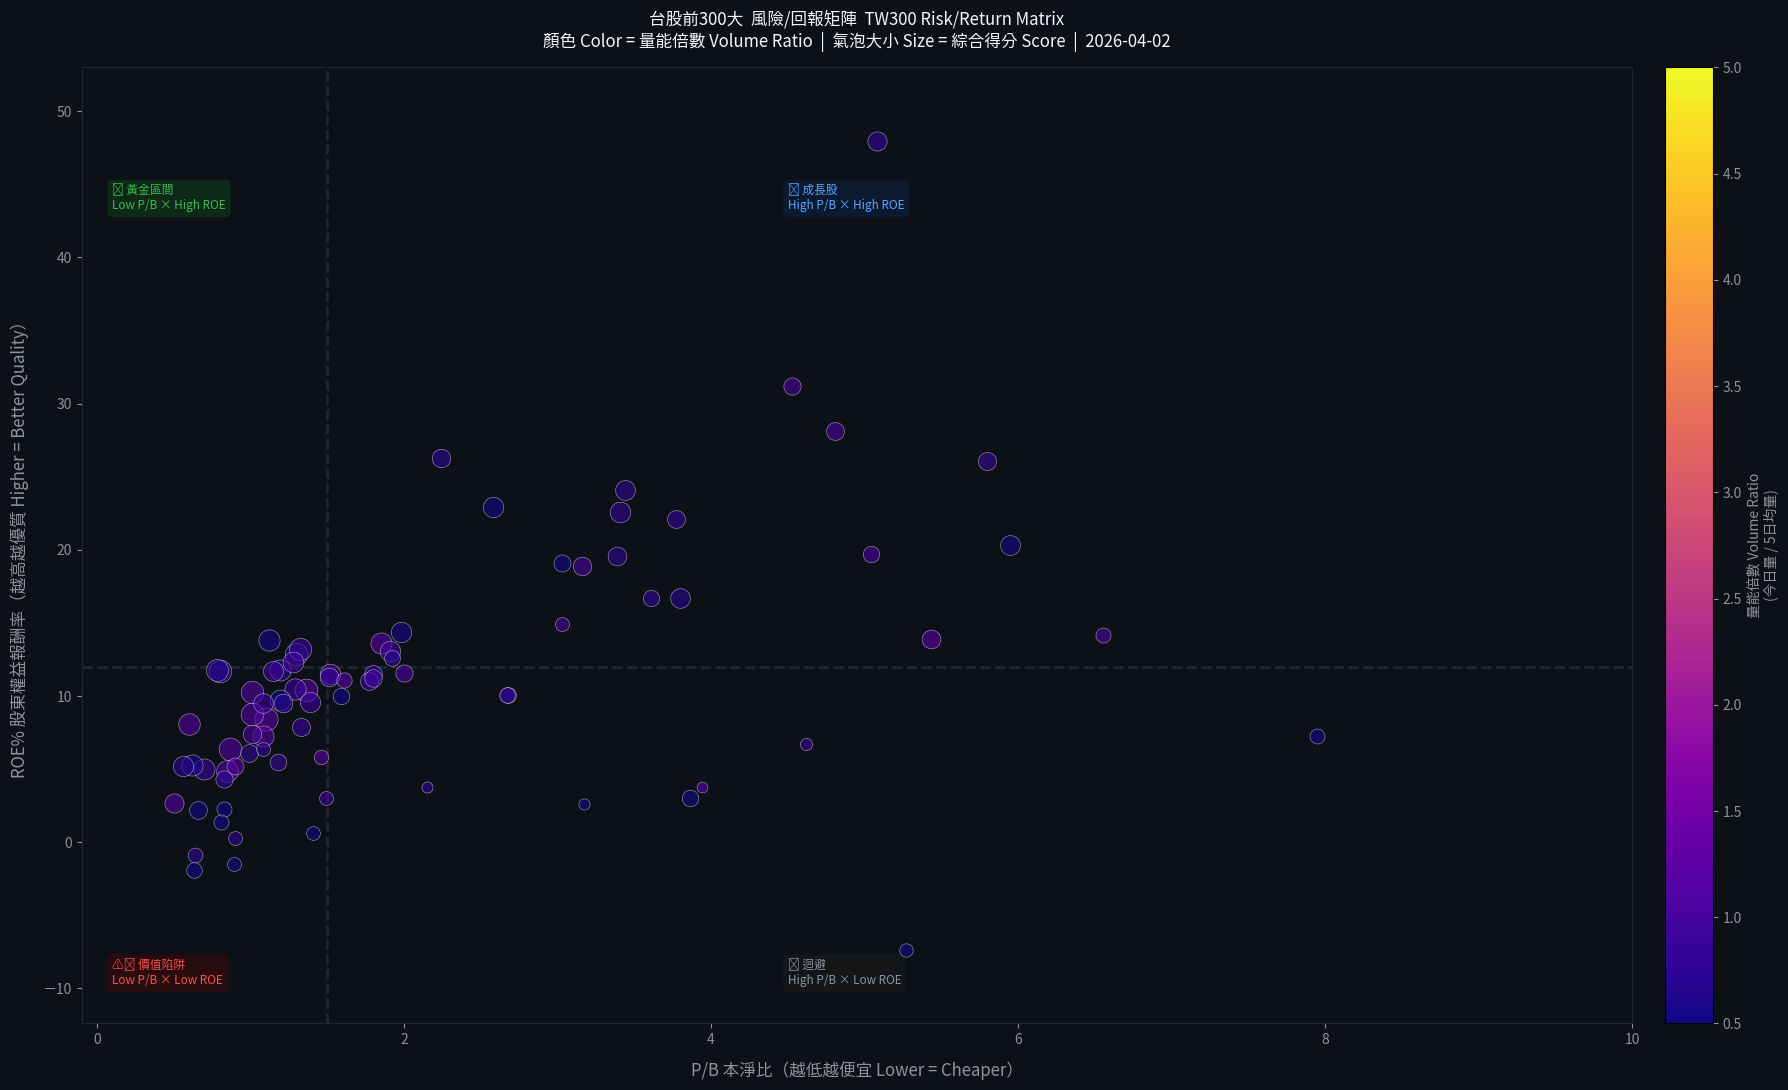


📊 矩陣圖已儲存 Saved: tw300_matrix.png


In [10]:
def plot_risk_reward_matrix(df: pd.DataFrame, figsize=(18, 11)):
    """
    繪製 P/B vs ROE 風險/回報矩陣圖
    Plot P/B vs ROE Risk/Return Matrix
    - 顏色 Color = 量能倍數 Volume Ratio (plasma colormap)
    - 氣泡大小 Size = 綜合得分 Composite Score
    """
    plot_df = df.dropna(subset=["PB本淨比","ROE%"]).copy()
    # 過濾極端值，保持圖表可讀
    plot_df = plot_df[
        (plot_df["PB本淨比"] < 8) &
        (plot_df["ROE%"].between(-10, 50))
    ]

    if len(plot_df) == 0:
        print("⚠️ 無足夠數據繪圖 | Insufficient data for plotting")
        return

    fig, ax = plt.subplots(figsize=figsize, facecolor='#0D1117')
    ax.set_facecolor('#0D1117')

    # 象限分割線
    ax.axvline(x=1.5, color='#21262D', linewidth=2, linestyle='--', alpha=1, zorder=1)
    ax.axhline(y=12,  color='#21262D', linewidth=2, linestyle='--', alpha=1, zorder=1)

    # 顏色映射（量能倍數）plasma: 黑→紫→橙→黃，越亮量能越強
    vol_vals = plot_df["量能倍數"].clip(0.5, 5.0)
    norm = mcolors.Normalize(vmin=0.5, vmax=5.0)
    cmap = plt.cm.plasma

    # 氣泡大小（綜合得分）
    sc_min, sc_max = plot_df["綜合得分"].min(), plot_df["綜合得分"].max()

    for _, row in plot_df.iterrows():
        pb    = row["PB本淨比"]
        roe   = row["ROE%"]
        vol   = min(row.get("量能倍數", 1.0), 5.0)
        score = row.get("綜合得分", 30)
        label = str(row.get("探勘結論", ""))

        size_n   = (score - sc_min) / max(sc_max - sc_min, 1)
        bubble_s = 60 + size_n * 220

        color  = cmap(norm(vol))
        marker = '*' if "絕佳寶藏" in label else ('D' if "超跌黃金" in label else 'o')
        alpha  = 0.95 if score > 70 else 0.6

        ax.scatter(pb, roe, c=[color], s=bubble_s, marker=marker,
                   alpha=alpha, edgecolors='white', linewidth=0.4, zorder=5)

        # 高分標的才標名字 Only label high-score stocks
        if score > 65:
            ax.annotate(
                f"{row['代號']}\n{row['名稱']}",
                (pb, roe),
                textcoords="offset points", xytext=(6, 3),
                fontsize=6.5, color='#E6EDF3', zorder=6
            )

    # 色條 Color bar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("量能倍數 Volume Ratio\n(今日量 / 5日均量)", color='#8B949E', fontsize=10)
    cbar.ax.yaxis.set_tick_params(color='#8B949E')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#8B949E')

    # 象限標籤
    for x, y, txt, fc, bg in [
        (0.1, 45,  '🏆 黃金區間\nLow P/B × High ROE',    '#3FB950', '#0D3B1A'),
        (4.5, 45,  '✨ 成長股\nHigh P/B × High ROE',      '#58A6FF', '#0A2040'),
        (0.1, -8,  '⚠️ 價值陷阱\nLow P/B × Low ROE',     '#F85149', '#3B0A0A'),
        (4.5, -8,  '🚫 迴避\nHigh P/B × Low ROE',         '#8B949E', '#1A1A1A'),
    ]:
        ax.text(x, y, txt, fontsize=8.5, color=fc, va='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=bg, alpha=0.6, edgecolor='none'))

    ax.set_xlabel("P/B 本淨比（越低越便宜 Lower = Cheaper）", color='#8B949E', fontsize=12, labelpad=10)
    ax.set_ylabel("ROE% 股東權益報酬率（越高越優質 Higher = Better Quality）", color='#8B949E', fontsize=12, labelpad=10)
    ax.set_title(
        f"台股前300大  風險/回報矩陣  TW300 Risk/Return Matrix\n"
        f"顏色 Color = 量能倍數 Volume Ratio  |  氣泡大小 Size = 綜合得分 Score  |  {datetime.now().strftime('%Y-%m-%d')}",
        color='#F0F6FC', fontsize=12, pad=15
    )
    ax.tick_params(colors='#8B949E')
    for spine in ax.spines.values():
        spine.set_color('#21262D')

    x_max = min(float(plot_df["PB本淨比"].max()) * 1.2 + 0.5, 10.0)
    ax.set_xlim(-0.1, x_max)
    ax.set_ylim(float(plot_df["ROE%"].min()) - 5, float(plot_df["ROE%"].max()) + 5)

    plt.tight_layout()
    plt.savefig("tw300_matrix.png", dpi=150, bbox_inches='tight',
                facecolor='#0D1117', edgecolor='none')
    plt.show()
    print("\n📊 矩陣圖已儲存 Saved: tw300_matrix.png")


plot_risk_reward_matrix(df)


## 💾 Step 9: 匯出報表 | Export Report

**中文：** CSV 支援 Excel 開啟（`utf-8-sig` 編碼，中文不亂碼）。在 Colab 中會自動下載。  
**English:** CSV compatible with Excel (`utf-8-sig` encoding). Auto-downloads in Google Colab.


In [11]:
# ── 儲存 CSV ─────────────────────────────────────────────────────
ts_str   = datetime.now().strftime('%Y%m%d_%H%M')
csv_path = f"tw300_report_{ts_str}.csv"
df.to_csv(csv_path, index=True, encoding='utf-8-sig')
print(f"💾 完整報告已儲存 Report saved: {csv_path}")

# ── Google Colab 自動下載 ─────────────────────────────────────────
try:
    from google.colab import files
    files.download(csv_path)
    files.download("tw300_matrix.png")
    print("📥 Colab 正在下載檔案 | Downloading files...")
except ImportError:
    print("💡 本機模式：檔案已在當前目錄 | Local mode: files saved in current directory")

# ── 最終統計摘要 ─────────────────────────────────────────────────
print("\n" + "─"*60)
print("📊 最終分析摘要 | Final Analysis Summary")
print("─"*60)
print(f"  分析總數 Total analyzed:      {len(df):>4} 檔")
print(f"  有任一信號 Any signal:         {len(df[df['探勘結論'] != '— 一般觀察']):>4} 檔")
print(f"  💎 絕佳寶藏:                  {len(df[df['探勘結論'].str.contains('絕佳寶藏',na=False)]):>4} 檔")
print(f"  🚀 真突破:                    {len(df[df['探勘結論'].str.contains('真突破',na=False)]):>4} 檔")
print(f"  ⭐ 超跌黃金:                  {len(df[df['探勘結論'].str.contains('超跌黃金',na=False)]):>4} 檔")
print(f"  ⚠️  假性反彈警示:              {len(df[df['探勘結論'].str.contains('假性反彈',na=False)]):>4} 檔")
print(f"  🔥 最強訊號（3條件同滿足）:   {len(df[(df['綜合得分']>80)&(df['年線乖離%']<-20)&(df['量能倍數']>2.5)]):>4} 檔")
print("─"*60)
print("\n✅ 分析完成！下次只需重新 Run All 即可更新最新數據")
print("   All done! Just re-run all cells next time for fresh data")


💾 完整報告已儲存 Report saved: tw300_report_20260402_0500.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Colab 正在下載檔案 | Downloading files...

────────────────────────────────────────────────────────────
📊 最終分析摘要 | Final Analysis Summary
────────────────────────────────────────────────────────────
  分析總數 Total analyzed:       135 檔
  有任一信號 Any signal:           22 檔
  💎 絕佳寶藏:                     0 檔
  🚀 真突破:                       0 檔
  ⭐ 超跌黃金:                     0 檔
  ⚠️  假性反彈警示:                17 檔
  🔥 最強訊號（3條件同滿足）:      0 檔
────────────────────────────────────────────────────────────

✅ 分析完成！下次只需重新 Run All 即可更新最新數據
   All done! Just re-run all cells next time for fresh data
